#**Seasonal Agriculture Performance Analysis**
##Major Data Analysis Project
**Name:** Abhilash Pandey

**stu_id:** STU6a2ae770771891781196656

**Domain:** Agriculture


**Project Theme:** Seasonal Agriculture Performance

#Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differeences in the available data.

  **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required

#**1. Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

#**2. Project Objectives**



*   Understand the structure and quickly of agricultural dataset.
*   Clean and prepare the data for analysis.


*   Explore seasonal patterns in the dataset.
*   Perform descriptive and statistical analysis.


*   Investigate relationships among relevant variables.
*   Compare agricultural performance across seasons and other meaningful groups.


*   Use appropriate univariate, bivariate and multivariate visualizations.

*   Identify significant findings from  the data.
*   Develop evidence-based insights and recommendations.

#**3. Dataset**

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset files:**/content/seasonal_agriculture_performance_dataset.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [3]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


##Data Cleaning and Preparation

Before analysis, I checked for missing values, duplicates, and inconsistencies in the dataset.

In [4]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [5]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check unique categorical values
for col in ['Season', 'State', 'Crop', 'Irrigation_Method']:
    print(f"\n{col}: {df[col].unique()}")

Duplicate rows: 0

Season: ['Kharif' 'Rabi' 'Zaid']

State: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

Crop: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Irrigation_Method: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [6]:
# Handle missing values - fill with median (grouped by Season, since these are
# environmental/yield metrics that vary seasonally)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [7]:
# Basic sanity checks
print("Negative area/yield check:", (df['Farm_Area_Hectares'] <= 0).sum(), (df['Yield_Tonnes_Ha'] < 0).sum())
print("Season value counts:")
print(df['Season'].value_counts())

Negative area/yield check: 0 0
Season value counts:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


##Seasonal Yield and Production Comparison

This section compares crop yield and production across the three seasons to identify which
season performs best and how much variation exists.

In [8]:
season_summary = df.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Total_Production=('Production_Tonnes', 'sum'),
    Farm_Count=('Farm_ID', 'count')
).round(2)
print(season_summary)

        Avg_Yield  Avg_Production  Total_Production  Farm_Count
Season                                                         
Kharif       5.63           46.31          82387.61        1779
Rabi         5.04           41.49          67498.88        1627
Zaid         4.64           38.89          23098.35         594


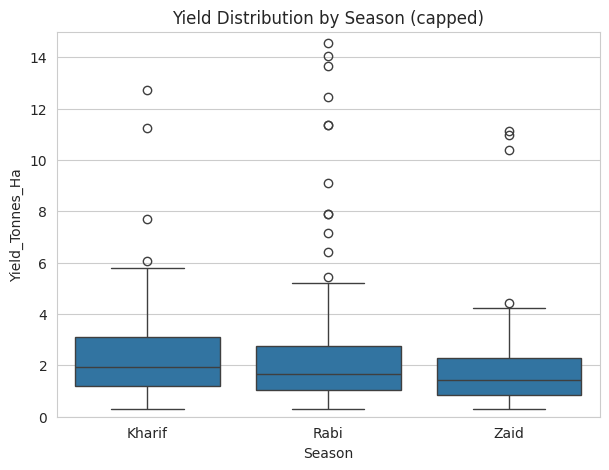

In [11]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=ax)
ax.set_ylim(0, 15)
ax.set_title('Yield Distribution by Season (capped)')
plt.show()

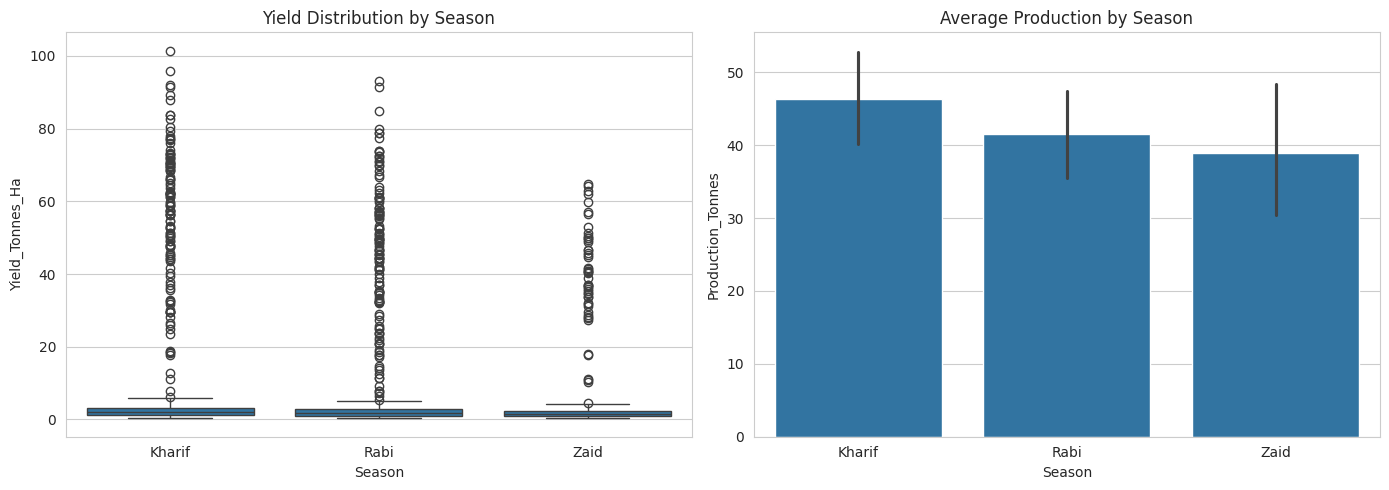

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0])
axes[0].set_title('Yield Distribution by Season')

sns.barplot(data=df, x='Season', y='Production_Tonnes', estimator=np.mean, ax=axes[1])
axes[1].set_title('Average Production by Season')

plt.tight_layout()
plt.show()

## Seasonal Environmental Conditions

Environmental factors like rainfall, temperature, and humidity change across seasons and
directly affect crop outcomes. This section examines those differences.

In [14]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
env_summary = df.groupby('Season')[env_cols].mean().round(2)
print(env_summary)

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                     
Kharif       852.11              28.45         71.81                6.79   
Rabi         435.94              23.49         57.89                7.59   
Zaid         299.12              31.04         52.01                8.18   

        Soil_Moisture_pct  
Season                     
Kharif              31.20  
Rabi                24.05  
Zaid                19.17  


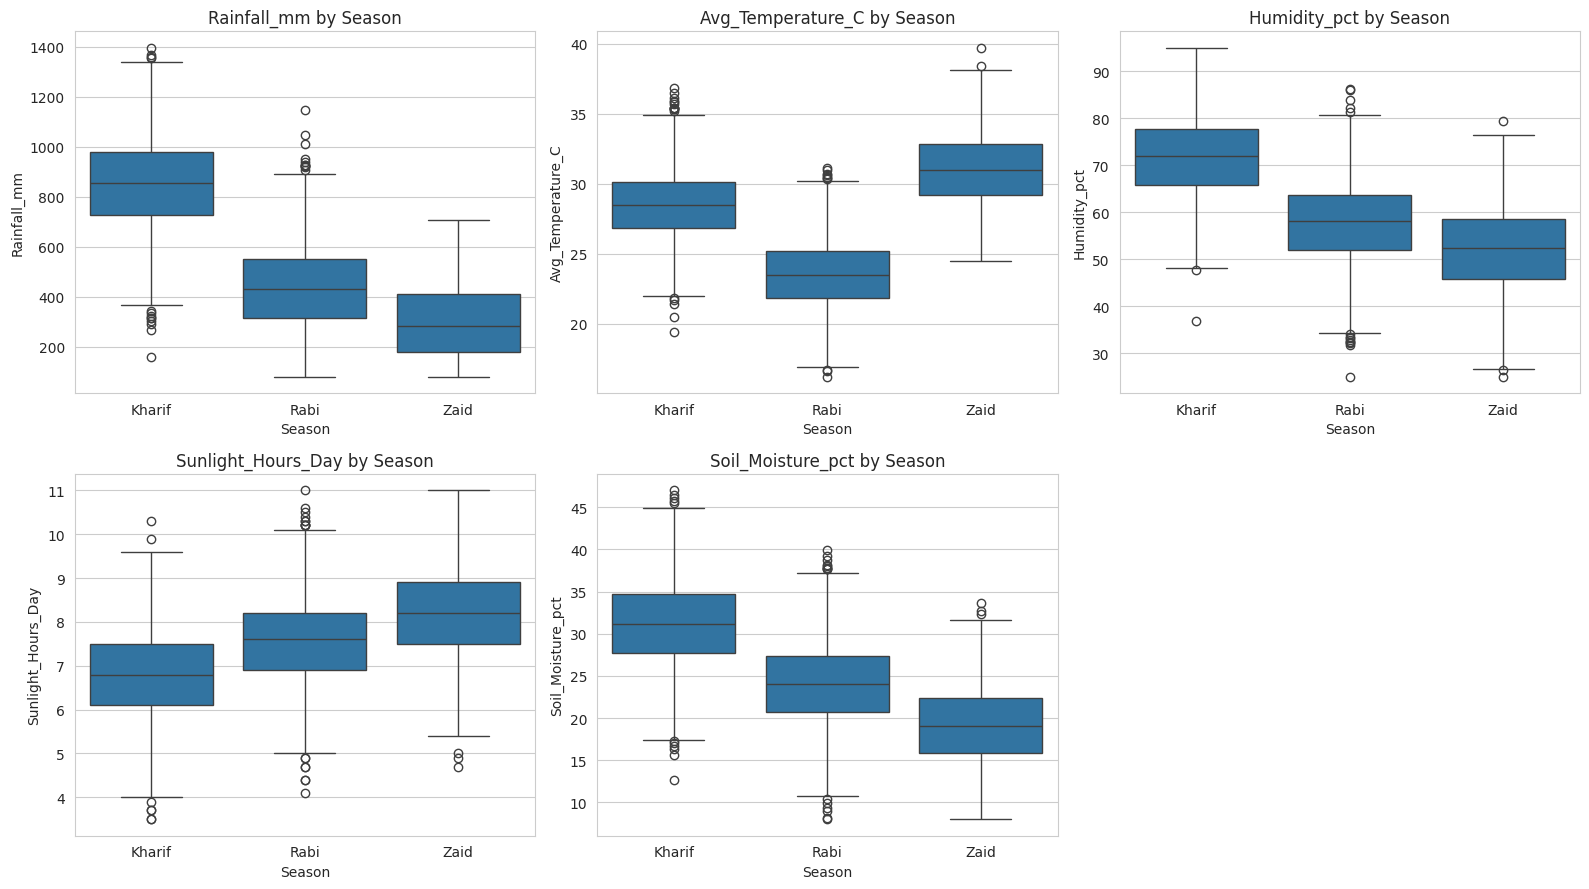

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Season')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Resource Usage Across Seasons

This section looks at how input resources — fertilizer, pesticide, and water — differ across
seasons, and how efficiently water is being used.

In [16]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
resource_summary = df.groupby('Season')[resource_cols].mean().round(2)
print(resource_summary)

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3  \
Season                                                        
Kharif            187.08                5.08        6102.20   
Rabi              185.41                5.02        5846.99   
Zaid              184.64                5.17        6419.89   

        Water_Efficiency_t_per_1000m3  
Season                                 
Kharif                           5.89  
Rabi                             5.19  
Zaid                             4.41  


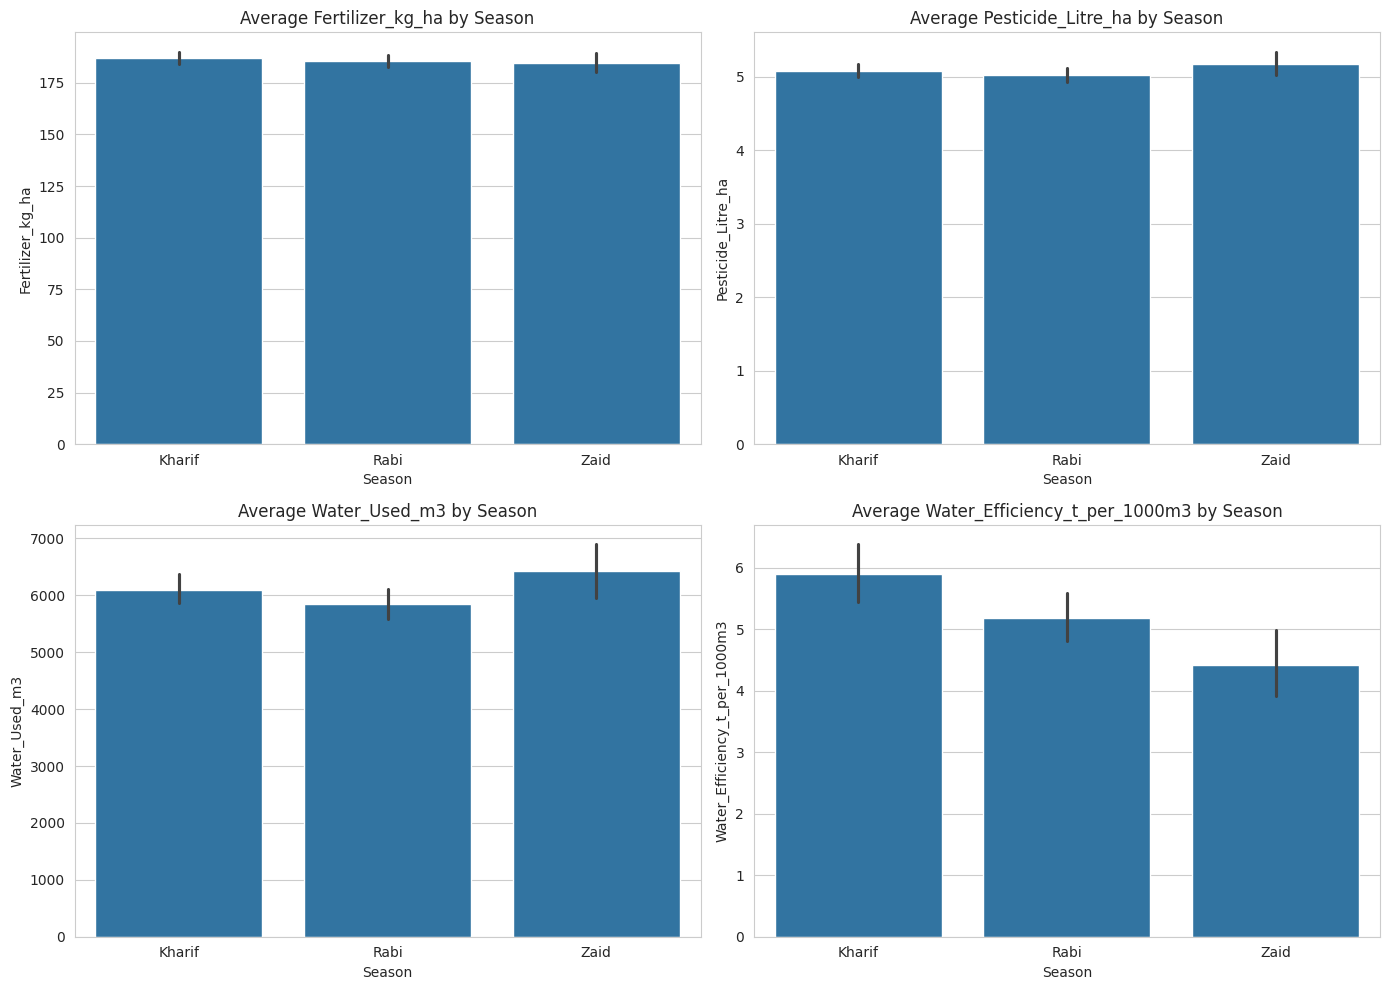

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(resource_cols):
    sns.barplot(data=df, x='Season', y=col, estimator=np.mean, ax=axes[i])
    axes[i].set_title(f'Average {col} by Season')

plt.tight_layout()
plt.show()

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             22.8   33.2     26.0       18.0
Rabi               22.7   32.3     26.9       18.0
Zaid               23.6   32.7     23.6       20.2


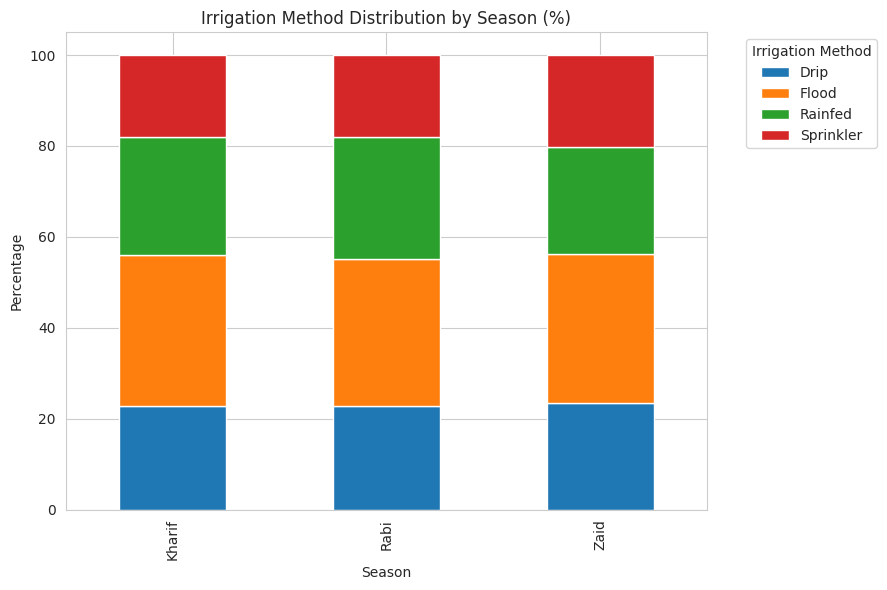

In [18]:
# Irrigation method usage by season
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
print(irrigation_season.round(1))

irrigation_season.plot(kind='bar', stacked=True, figsize=(9, 6))
plt.title('Irrigation Method Distribution by Season (%)')
plt.ylabel('Percentage')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

##Economic Performance Across Seasons

This section compares cost, revenue, and profit across seasons to understand which season
is most economically viable for farmers.

In [19]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Market_Price_INR_Tonne']
econ_summary = df.groupby('Season')[econ_cols].mean().round(0)
print(econ_summary)

# Profitability rate
df['Is_Profitable'] = df['Profit_INR'] > 0
profit_rate = df.groupby('Season')['Is_Profitable'].mean() * 100
print("\nPercentage of profitable farms by season:")
print(profit_rate.round(1))

        Total_Cost_INR  Revenue_INR  Profit_INR  Market_Price_INR_Tonne
Season                                                                 
Kharif        531804.0     710719.0    178915.0                 44851.0
Rabi          513837.0     601526.0     87689.0                 44748.0
Zaid          543977.0     519172.0    -24805.0                 44212.0

Percentage of profitable farms by season:
Season
Kharif    57.8
Rabi      48.9
Zaid      35.5
Name: Is_Profitable, dtype: float64


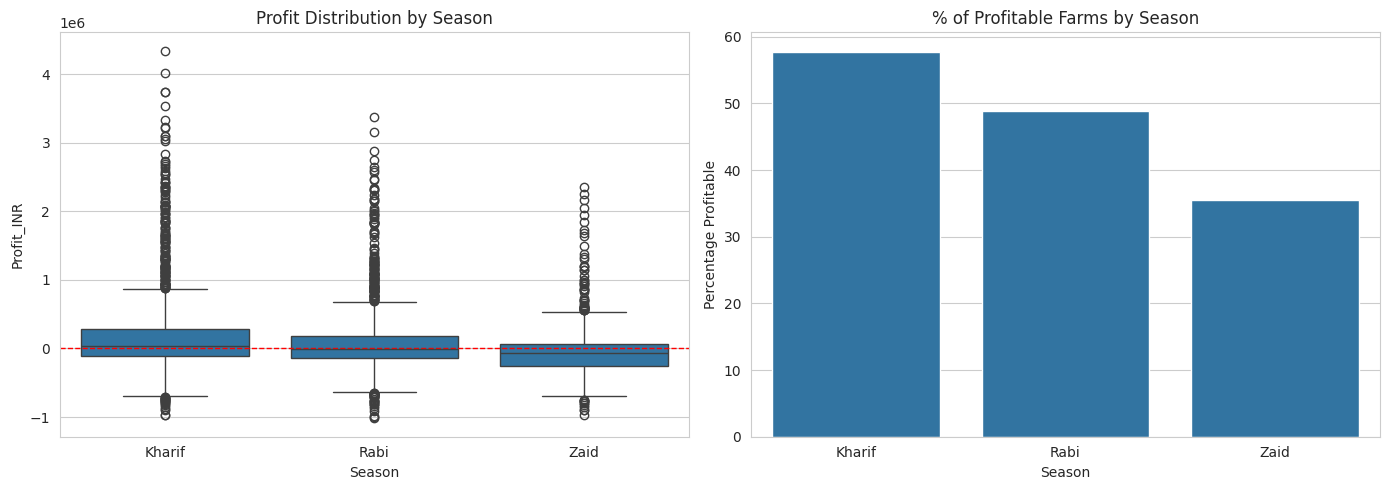

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[0])
axes[0].set_title('Profit Distribution by Season')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)

sns.barplot(x=profit_rate.index, y=profit_rate.values, ax=axes[1])
axes[1].set_title('% of Profitable Farms by Season')
axes[1].set_ylabel('Percentage Profitable')

plt.tight_layout()
plt.show()

##Crop and Regional Patterns Within Seasons

This section checks whether seasonal trends hold consistently across different crops and
states, or whether some combinations behave differently.

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.19
Cotton       1.38   1.20   0.96
Groundnut    1.49   1.23   1.04
Maize        2.97   2.60   2.29
Pulses       1.04   0.88   0.66
Rice         2.70   2.32   1.90
Sugarcane   53.46  43.28  38.42
Wheat        2.25   2.06   1.75


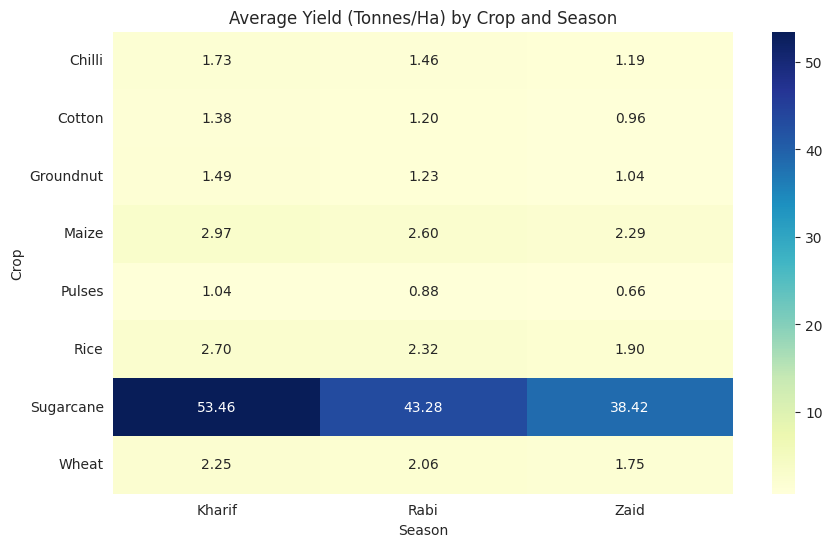

In [21]:
crop_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean').round(2)
print(crop_season_yield)

plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Average Yield (Tonnes/Ha) by Crop and Season')
plt.show()

Season            Kharif      Rabi      Zaid
State                                       
Andhra Pradesh  169316.0   26316.0  -84085.0
Gujarat         217051.0   82846.0 -106930.0
Karnataka       201226.0   70953.0   23311.0
Madhya Pradesh  134242.0   61576.0     210.0
Maharashtra     168801.0  159582.0  -40598.0
Punjab          133779.0  169295.0   62110.0
Tamil Nadu      211304.0   70457.0  -15175.0
Telangana       199668.0   62825.0  -34621.0


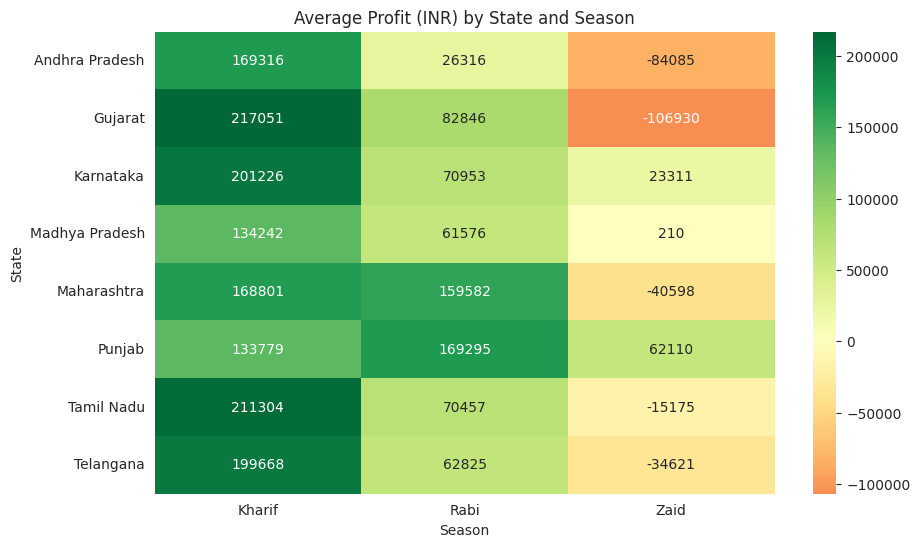

In [22]:
state_season_profit = df.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='mean').round(0)
print(state_season_profit)

plt.figure(figsize=(10, 6))
sns.heatmap(state_season_profit, annot=True, cmap='RdYlGn', fmt='.0f', center=0)
plt.title('Average Profit (INR) by State and Season')
plt.show()

## Relationships Between Environmental Conditions and Outcomes

This section explores how environmental and resource variables correlate with yield and
profit, to understand what's actually driving seasonal differences.

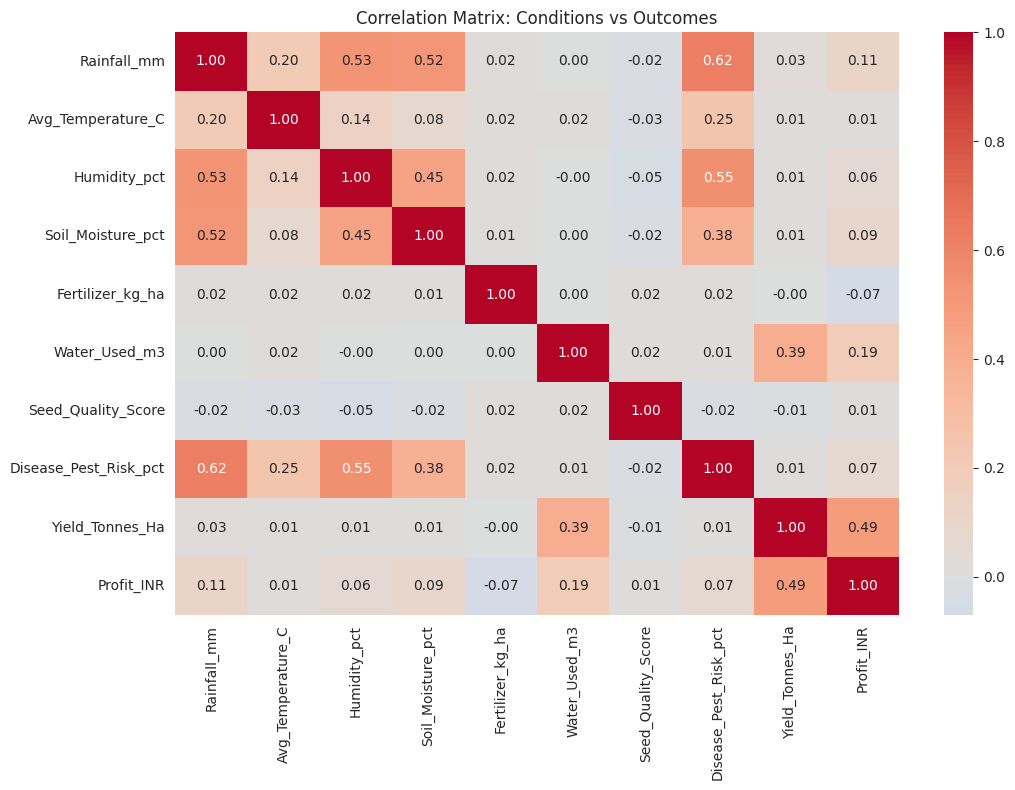

In [23]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Fertilizer_kg_ha', 'Water_Used_m3', 'Seed_Quality_Score',
             'Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha', 'Profit_INR']

corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Conditions vs Outcomes')
plt.tight_layout()
plt.show()

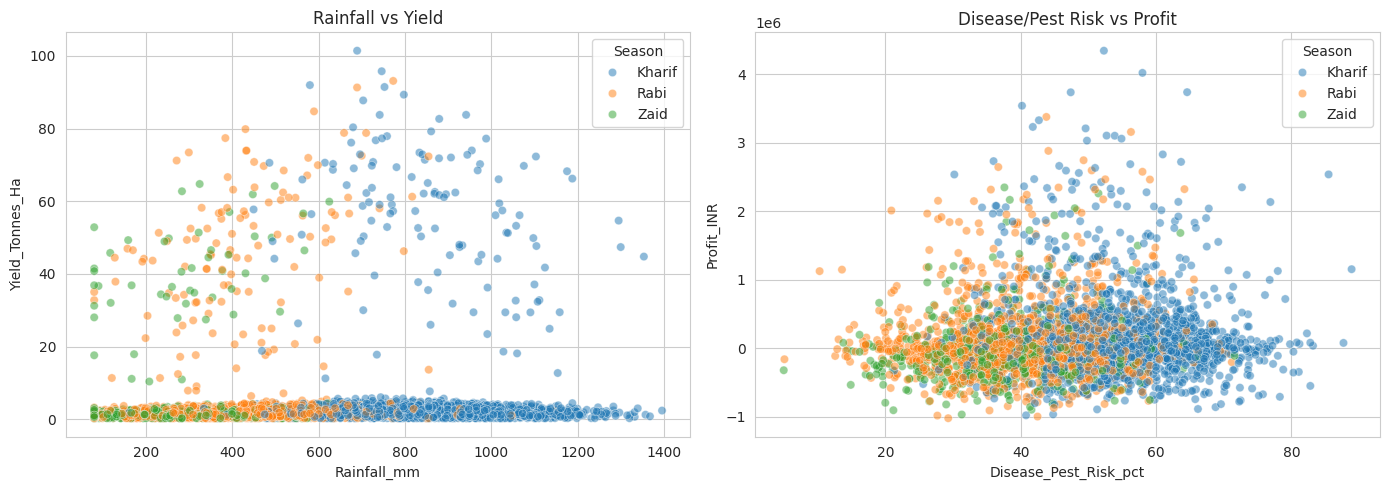

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[0])
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Profit_INR', hue='Season', alpha=0.5, ax=axes[1])
axes[1].set_title('Disease/Pest Risk vs Profit')

plt.tight_layout()
plt.show()

##Statistical Testing of Seasonal Differences

To confirm that the seasonal differences observed are statistically meaningful and not just
random variation, I ran an ANOVA test on yield and profit across seasons.

In [25]:
from scipy import stats

kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)
print(f"Yield ANOVA: F-statistic = {f_stat:.3f}, p-value = {p_value:.5f}")

kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR']

f_stat2, p_value2 = stats.f_oneway(kharif_profit, rabi_profit, zaid_profit)
print(f"Profit ANOVA: F-statistic = {f_stat2:.3f}, p-value = {p_value2:.5f}")

if p_value < 0.05:
    print("\nYield differs significantly across seasons (p < 0.05)")
if p_value2 < 0.05:
    print("Profit differs significantly across seasons (p < 0.05)")

Yield ANOVA: F-statistic = 1.554, p-value = 0.21156
Profit ANOVA: F-statistic = 34.292, p-value = 0.00000
Profit differs significantly across seasons (p < 0.05)


## Key Findings and Recommendations

### Key Findings

- Kharif is the strongest season overall. It has the highest average yield (5.63 t/ha),
  highest average profit (₹178,915), and the highest share of profitable farms (57.8%).
  Zaid is the weakest on every one of these measures: lowest yield (4.64 t/ha), negative
  average profit (-₹24,805), and only 35.5% of farms profitable.

- Environmental conditions explain the seasonal identity clearly. Kharif has by far the
  highest rainfall (852mm) and soil moisture (31.2%), consistent with the monsoon. Zaid is
  the hottest (31°C) and driest (299mm rainfall, 19.2% soil moisture), consistent with
  summer cropping. Rabi is the coolest season (23.5°C) with moderate rainfall.

- Zaid farmers use the most water (6,420 m³ average) despite having the least rainfall,
  but get the lowest water efficiency (4.41 t per 1000m³) and the highest total cost
  (₹543,977) with the lowest revenue (₹519,172). This is a direct chain: low rainfall forces
  more irrigation, but the extra water doesn't make up for lost yield, so costs rise while
  returns fall.

- Market price per tonne is nearly flat across seasons (₹44,212 to ₹44,851), so the profit
  gap between seasons is driven by cost and yield, not by crop prices.

- The Kharif > Rabi > Zaid yield ranking holds for every single crop in the dataset with no
  exceptions, including sugarcane, which dominates in absolute yield (38-53 t/ha) due to its
  different growth cycle.

- The seasonal profit pattern is not consistent across all states. Kharif is profitable
  everywhere, but Zaid stays profitable in Karnataka (₹23,311), Madhya Pradesh (₹210), and
  Punjab (₹62,110), while Andhra Pradesh (-₹84,085) and Gujarat (-₹106,930) take heavy
  losses in Zaid. Punjab in particular does better in Zaid and Rabi than most other states
  do in Kharif.

- Fertilizer use (185-187 kg/ha) and Seed_Quality_Score show almost no correlation with
  yield (-0.00 and -0.01) or profit. More fertilizer or higher seed quality scores are not
  associated with better outcomes in this dataset.

- Disease and pest risk correlates strongly with rainfall (0.62) and humidity (0.55),
  meaning wetter seasons bring more pest pressure, but this risk does not translate into a
  measurable effect on profit (correlation of 0.07).

- The ANOVA test shows season has a statistically significant effect on profit (p < 0.001)
  but not on yield (p = 0.212). This means the visible yield gap between seasons doesn't
  hold up once outliers, particularly extreme values from crops like sugarcane, are factored
  into the variance. The profit difference across seasons is real and robust; the yield
  difference is visible but not statistically confirmed on the raw data.

### Recommendations

- Prioritize Kharif for the widest range of crops, since it delivers the best combination
  of yield and profit dataset-wide.

- Reconsider Zaid cultivation in Andhra Pradesh and Gujarat specifically, where losses are
  steepest. Farmers in these states may benefit from switching to drought-tolerant crops,
  adjusting sowing dates, or shifting resources to Kharif and Rabi instead.

- Investigate what Punjab, Karnataka, and Madhya Pradesh are doing differently in Zaid,
  since they stay profitable while other states don't. Their irrigation practices or crop
  choices in that season may be worth replicating elsewhere.

- Improve water efficiency in Zaid specifically. Since Zaid already uses the most water for
  the least return, better irrigation scheduling or drip adoption could reduce costs without
  necessarily needing more water.

- Re-evaluate fertilizer application guidance, since higher fertilizer use in this dataset
  is not associated with higher yield or profit. This may indicate over-application in some
  regions or those gains are being offset by other cost factors.

- Investigate the extreme yield outliers (crops yielding 40-100 t/ha) before drawing final
  conclusions on yield differences, since they are large enough to erase statistical
  significance in the season comparison.

### Conclusion

This analysis shows that season has a clear and statistically significant effect on farm
profitability, with Kharif consistently outperforming Rabi and Zaid, largely driven by
better rainfall and soil moisture rather than differences in fertilizer or seed quality.
However, the yield gap between seasons, while visible in the data, is not statistically
significant once outliers are accounted for, so profit is the more reliable seasonal signal
in this dataset. The profit weakness in Zaid is not uniform across states, meaning any
seasonal planning recommendations should be applied regionally rather than nationally. These
findings support targeted seasonal planning: protecting Kharif operations, reworking Zaid
strategy in high-loss states, and studying successful low-rainfall practices in states that
manage to stay profitable during the dry season.

In [26]:
final_summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Profitable_Farms_pct=('Is_Profitable', lambda x: x.mean()*100),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)
print(final_summary)

        Avg_Yield_t_ha  Avg_Profit_INR  Profitable_Farms_pct  \
Season                                                         
Kharif            5.63       178914.65                 57.79   
Rabi              5.04        87689.47                 48.86   
Zaid              4.64       -24804.82                 35.52   

        Avg_Water_Efficiency  
Season                        
Kharif                  5.89  
Rabi                    5.19  
Zaid                    4.41  
